# Exploratory Data Analysis (EDA) — Ozon User LTV

Данный ноутбук предназначен исключительно для исследовательского анализа данных (EDA) и визуализации.
Весь тяжелый код предобработки, расчета фичей и батчинга вынесен в модуль [`src/data.py`](file:///c:/Users/egorg/Documents/OZON_ECUP/src/data.py).

In [1]:
from datetime import timedelta
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт готовых оптимизированных методов из src.data
from src.data import read_fold, generate_cv_anchor_dates, FEATURES_DIR

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

## 1. Загрузка и первичный анализ сырых логов (`data/train.parquet`)

In [2]:
# Загрузка сырых логов через Polars
data = pl.read_parquet("data/train.parquet")

print(f"Формат таблицы: {data.shape[0]:,} строк, {data.shape[1]} колонок")
print(f"Временной диапазон: {data['event_date'].min()} — {data['event_date'].max()}")
print(f"Уникальных пользователей: {data['user_id'].n_unique():,}")

data.head(5)

Формат таблицы: 30,631,006 строк, 18 колонок
Временной диапазон: 2025-01-01 — 2026-02-13
Уникальных пользователей: 250,000


event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,i64
2025-06-16,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,2
2025-06-22,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-08,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2025-08-18,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-23,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1


## 2. Динамика активности пользователей и GMV по дням

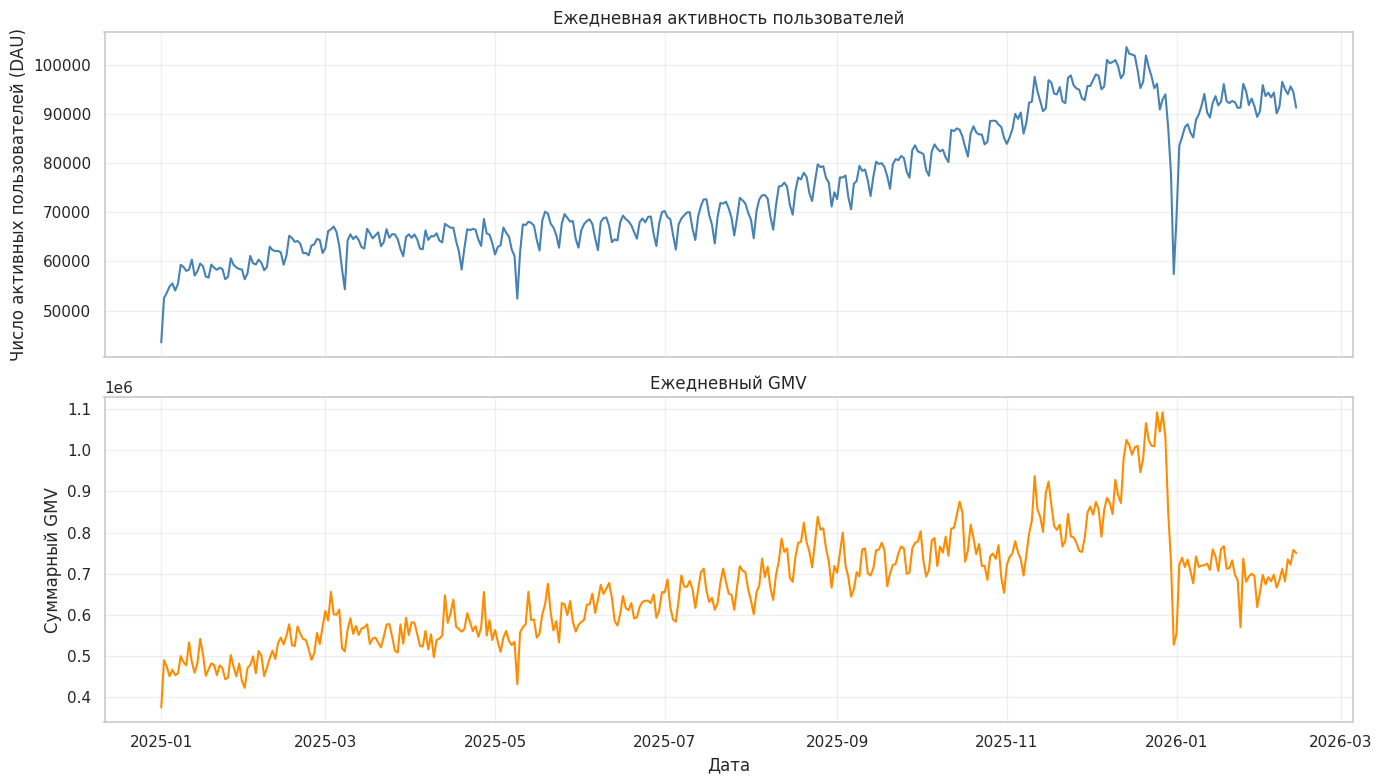

In [3]:
# Быстрый нативный расчет дневных агрегатов в Polars
daily_agg = (
    data.group_by("event_date")
    .agg(
        pl.len().alias("n_users"),
        pl.sum("gmv").alias("gmv_sum"),
        pl.sum("searches").alias("searches_sum"),
        pl.sum("to_ord").alias("to_ord_sum"),
    )
    .sort("event_date")
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily_agg["event_date"], daily_agg["n_users"], color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Число активных пользователей (DAU)")
axes[0].set_title("Ежедневная активность пользователей")
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_agg["event_date"], daily_agg["gmv_sum"], color="darkorange", linewidth=1.5)
axes[1].set_ylabel("Суммарный GMV")
axes[1].set_title("Ежедневный GMV")
axes[1].grid(True, alpha=0.3)

plt.xlabel("Дата")
plt.tight_layout()
plt.show()

## 3. Якорные даты временного сплита (Time-CV Anchors)

In [4]:
# Получение якорных дат через функцию из src/data.py
anchors = generate_cv_anchor_dates(data, n_folds=4)

print("Сгенерированные якорные даты кросс-валидации (Time-CV):")
for i, a in enumerate(anchors):
    t_start = a + timedelta(days=1)
    t_end = a + timedelta(days=30)
    print(f"  Fold {i:02d}: Anchor Date = {a} (Прогноз LTV с {t_start} по {t_end})")

Сгенерированные якорные даты кросс-валидации (Time-CV):
  Fold 00: Anchor Date = 2025-12-03 (Прогноз LTV с 2025-12-04 по 2026-01-02)
  Fold 01: Anchor Date = 2025-12-17 (Прогноз LTV с 2025-12-18 по 2026-01-16)
  Fold 02: Anchor Date = 2025-12-31 (Прогноз LTV с 2026-01-01 по 2026-01-30)
  Fold 03: Anchor Date = 2026-01-14 (Прогноз LTV с 2026-01-15 по 2026-02-13)


## 4. Загрузка обработанного фолда (`fold_03`) через `src/data.py`

In [5]:
# Использование нативного считывателя read_fold из src.data
fold_03 = read_fold(FEATURES_DIR, "fold_03")

print(f"Загружен fold_03: {fold_03.shape[0]:,} юзеров, {fold_03.shape[1]} признаков")
fold_03.head(5)

Загружен fold_03: 250,000 юзеров, 27 признаков


anchor_date,user_id,gmv_sum_30d,gmv_max_30d,gmv_std_30d,gmv_mean_30d,searches_sum_30d,searches_max_30d,searches_std_30d,searches_mean_30d,gmv_sum_60d,gmv_max_60d,gmv_std_60d,gmv_mean_60d,searches_sum_60d,searches_max_60d,searches_std_60d,searches_mean_60d,gmv_sum_90d,gmv_max_90d,gmv_std_90d,gmv_mean_90d,searches_sum_90d,searches_max_90d,searches_std_90d,searches_mean_90d,target
date,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-14,2,16.315287,16.315287,8.157644,4.078822,13.0,5.0,1.5,3.25,0.0,0.0,0.0,0.0,9.0,9.0,0.0,9.0,0.0,0.0,0.0,0.0,7.0,5.0,2.309401,2.333333,0.0
2026-01-14,7,288.283114,257.468616,68.67056,20.591651,42.0,17.0,4.402796,3.0,181.124603,70.065728,27.937945,15.093717,32.0,5.0,1.61433,2.666667,28.615134,16.246318,7.955584,5.723027,7.0,2.0,0.547723,1.4,486.96535
2026-01-14,15,2264.174894,2237.575574,620.005196,174.1673,26.0,14.0,3.719319,2.0,133.692441,133.692441,42.277262,13.369244,8.0,2.0,0.788811,0.8,0.0,0.0,0.0,0.0,4.0,4.0,0.0,4.0,0.0
2026-01-14,18,584.802181,250.101994,64.463223,30.779062,55.0,10.0,3.413938,2.894737,25.739683,25.739683,6.645958,1.715979,38.0,23.0,5.717975,2.533333,227.428092,168.281835,51.870829,22.742809,17.0,7.0,1.946507,1.7,276.0091
2026-01-14,23,0.0,0.0,0.0,0.0,10.0,5.0,1.527525,3.333333,0.0,0.0,0.0,0.0,5.0,4.0,2.12132,2.5,0.0,0.0,0.0,0.0,18.0,9.0,3.224903,3.0,0.0


## 5. Анализ распределения таргета (Zero-Inflation и Тяжёлый хвост)

In [8]:
from statistics import quantiles
target = fold_03["target"].to_numpy()
total_users = len(target)
zeros = (target == 0).sum()
positives = (target > 0).sum()

print("=" * 60)
print(f"Всего пользователей: {total_users:,}")
print(f"Нулевой GMV (Zero Inflation): {zeros:,} ({zeros / total_users * 100:.2f}%)")
print(f"Положительный GMV: {positives:,} ({positives / total_users * 100:.2f}%)")
print("=" * 60)

quantiles = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]

print("\nКвантили трат среди ВСЕХ пользователей:")
for q, val in zip(quantiles, np.quantile(target, quantiles)):
    print(f"  {q * 100:5.1f}%: {val:10.2f}")

pos_target = target[target > 0]
print("\nКвантили трат среди ПОКУПАТЕЛЕЙ (GMV > 0):")
for q, val in zip(quantiles, np.quantile(pos_target, quantiles)):
    print(f"  {q * 100:5.1f}%: {val:10.2f}")

Всего пользователей: 250,000
Нулевой GMV (Zero Inflation): 114,835 (45.93%)
Положительный GMV: 135,165 (54.07%)

Квантили трат среди ВСЕХ пользователей:
   50.0%:       7.89
   75.0%:      70.52
   90.0%:     215.86
   95.0%:     383.46
   99.0%:    1040.14
   99.9%:    2933.56
  100.0%:   53746.95

Квантили трат среди ПОКУПАТЕЛЕЙ (GMV > 0):
   50.0%:      61.36
   75.0%:     159.68
   90.0%:     361.67
   95.0%:     587.47
   99.0%:    1396.32
   99.9%:    3609.81
  100.0%:   53746.95


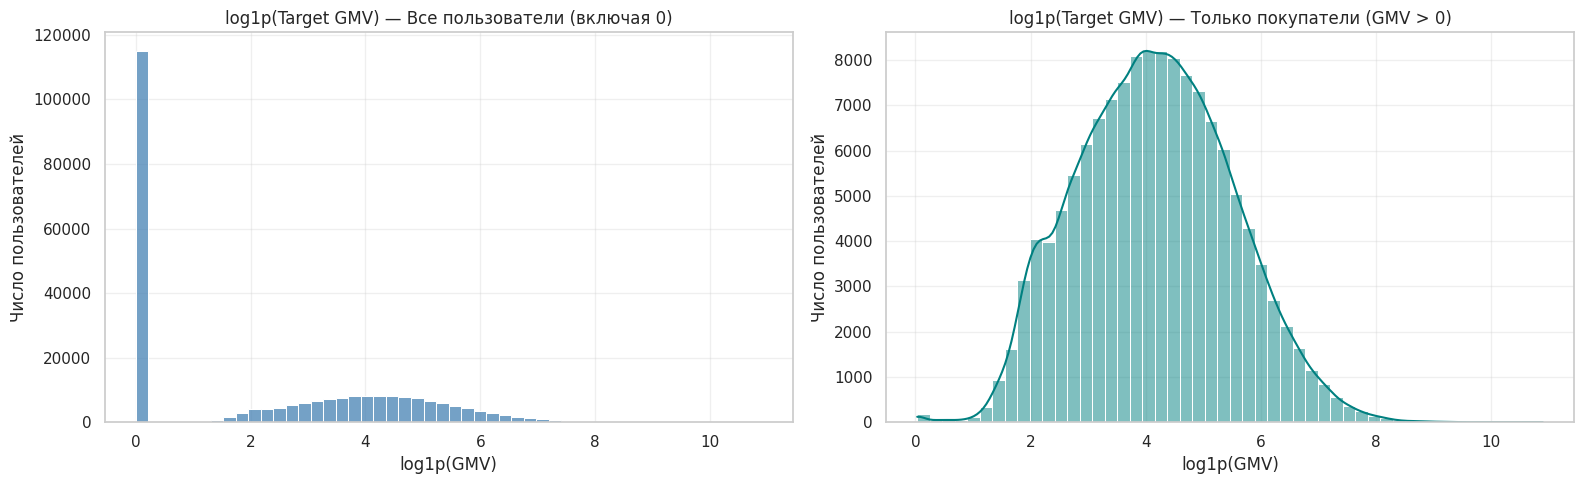

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(np.log1p(target), bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("log1p(Target GMV) — Все пользователи (включая 0)")
axes[0].set_xlabel("log1p(GMV)")
axes[0].set_ylabel("Число пользователей")
axes[0].grid(True, alpha=0.3)

sns.histplot(np.log1p(pos_target), bins=50, ax=axes[1], color="teal", kde=True)
axes[1].set_title("log1p(Target GMV) — Только покупатели (GMV > 0)")
axes[1].set_xlabel("log1p(GMV)")
axes[1].set_ylabel("Число пользователей")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Корреляция сгенерированных признаков с таргетом

Топ наиболее коррелирующих признаков с таргетом:
shape: (24, 2)
┌───────────────────┬─────────────┐
│ feature           ┆ correlation │
│ ---               ┆ ---         │
│ str               ┆ f64         │
╞═══════════════════╪═════════════╡
│ gmv_sum_30d       ┆ 0.428504    │
│ gmv_sum_60d       ┆ 0.405804    │
│ gmv_sum_90d       ┆ 0.364816    │
│ gmv_max_30d       ┆ 0.30093     │
│ gmv_std_30d       ┆ 0.272884    │
│ …                 ┆ …           │
│ searches_mean_60d ┆ 0.182384    │
│ searches_std_30d  ┆ 0.17962     │
│ searches_std_60d  ┆ 0.176023    │
│ searches_mean_90d ┆ 0.175657    │
│ searches_std_90d  ┆ 0.172179    │
└───────────────────┴─────────────┘


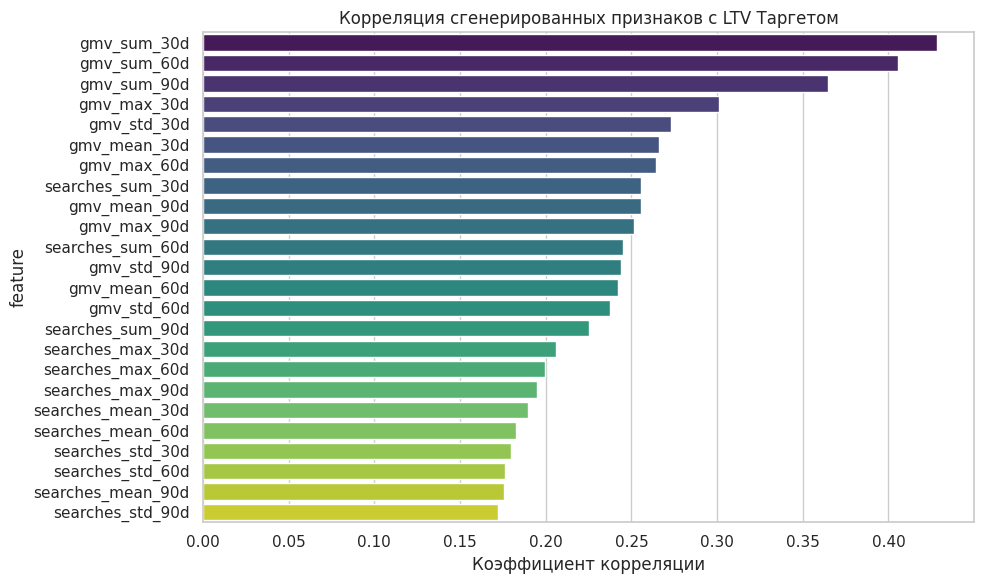

In [10]:
# Нативный векторный расчет корреляций признаков с таргетом в Polars
feature_cols = [c for c in fold_03.columns if c not in ["anchor_date", "user_id", "target"]]

corrs = []
for c in feature_cols:
    corr_val = fold_03.select(pl.corr(c, "target")).item()
    corrs.append((c, corr_val))

corr_df = pl.DataFrame(corrs, schema=["feature", "correlation"], orient="row").sort("correlation", descending=True)
print("Топ наиболее коррелирующих признаков с таргетом:")
print(corr_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=corr_df.to_pandas(),
    x="correlation",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)
plt.title("Корреляция сгенерированных признаков с LTV Таргетом")
plt.xlabel("Коэффициент корреляции")
plt.tight_layout()
plt.show()